# **Imports**

In [77]:
import numpy as np
import matplotlib.pyplot as plt
import os
!pip install methcomp
import methcomp
import torch
import torch.optim as optim
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import scipy.io as scio
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from tqdm.notebook import tqdm, trange
torch.__version__




[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


'2.5.1+cpu'

# **Mount Drive**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Seed**

In [9]:
SEED = 101

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

g = torch.Generator()
g.manual_seed(SEED)

# **ResNet blocks**

<p align="center">
  <b>Convolution Block</b><br>
  <img src="https://drive.google.com/thumbnail?id=1Mc49Hd8zhAyYFbDQ_gF-l6N1xj9NkMEq&sz=w1000" width="200" height="500"><br>
</p>

In [10]:
class ConvBlock(nn.Module):
    def __init__(self, in_channel, f, filters, p1, p2, p3, p4):
        super(ConvBlock,self).__init__()
        F1, F2, F3 = filters
        self.stage = nn.Sequential(
            nn.Conv2d(in_channel,F1,kernel_size=(1,1),stride=(1,2), padding=p1, bias=False),
            nn.BatchNorm2d(F1),
            nn.ReLU(True),
            nn.Conv2d(F1,F2,f,stride=1, padding=p2, bias=False),
            nn.BatchNorm2d(F2),
            nn.ReLU(True),
            nn.Conv2d(F2,F3,kernel_size=(1,1),stride=1, padding=p3, bias=False),
            nn.BatchNorm2d(F3),
        )
        self.shortcut_1 = nn.Conv2d(in_channel, F3, kernel_size=(1,1), stride=(1,2), padding=p4, bias=False)
        self.batch_1 = nn.BatchNorm2d(F3)
        self.relu_1 = nn.ReLU(True)

    def forward(self, X):
        X_shortcut = self.shortcut_1(X)
        X_shortcut = self.batch_1(X_shortcut)
        X = self.stage(X)
        X = X + X_shortcut
        X = self.relu_1(X)
        return X

<p align="center">
  <b>Identity Block</b><br>
  <img src="https://drive.google.com/thumbnail?id=1SpwtAoXW3RgNyvChEfRwuBGRfRJqeioG&sz=w1000" width="200" height="500"><br>
</p>

In [11]:
class IndentityBlock(nn.Module):
    def __init__(self, in_channel, f, filters, p1, p2, p3):
        super(IndentityBlock,self).__init__()
        F1, F2, F3 = filters
        self.stage = nn.Sequential(
            nn.Conv2d(in_channel,F1,kernel_size=(1,1),stride=1, padding=p1, bias=False),
            nn.BatchNorm2d(F1),
            nn.ReLU(True),
            nn.Conv2d(F1,F2,f,stride=1, padding=p2, bias=False),
            nn.BatchNorm2d(F2),
            nn.ReLU(True),
            nn.Conv2d(F2,F3,kernel_size=(1,1),stride=1, padding=p3, bias=False),
            nn.BatchNorm2d(F3),
        )
        self.relu_1 = nn.ReLU(True)

    def forward(self, X):
        X_shortcut = X
        X = self.stage(X)
        X = X + X_shortcut
        X = self.relu_1(X)
        return X


<p align="center">
  <b>Residual Block</b><br>
  <img src="https://drive.google.com/thumbnail?id=1Jz-XTGIx1TNR4REL5B-EgIwekeVlu9Zw&sz=w1000" width="500" height="300"><br>
  <b>DNN Compression</b><br>
  <img src="https://drive.google.com/thumbnail?id=1jRwWHMuOzyFgbNeSJQTe4-ql5EM0Hwpj&sz=w1000" width="500" height="300">
</p>

In [12]:
class ResModel(nn.Module):
    def __init__(self):
        super(ResModel,self).__init__()

        self.stage1 = nn.Sequential(
            nn.Conv2d(in_channels =1,out_channels =4,kernel_size=(1,6),stride=1, padding=0, bias=False),
            nn.BatchNorm2d(4),
            nn.ReLU(True),
            nn.MaxPool2d((1,2),padding=0),
        )
        self.stage2 = nn.Sequential(
            ConvBlock(4, f=(1,6), filters=[4, 4, 16],p1=(0,0),p2=(0,1),p3=(0,2),p4=(0,1)),
            IndentityBlock(16, (1,5), [4, 4, 16],p1=(0,1),p2=(0,1),p3=0),
            IndentityBlock(16, (1,5), [4, 4, 16],p1=(0,1),p2=(0,1),p3=0),
        )
        self.stage3 = nn.Sequential(
            ConvBlock(16, f=(1,6), filters=[8, 8, 32],p1=(0,0),p2=(0,1),p3=(0,2),p4=(0,1)),
            IndentityBlock(32, (1,5), [8, 8, 32],p1=(0,1),p2=(0,1),p3=0),
            IndentityBlock(32, (1,5), [8, 8, 32],p1=(0,1),p2=(0,1),p3=0),
            IndentityBlock(32, (1,5), [8, 8, 32],p1=(0,1),p2=(0,1),p3=0),
        )
        self.stage4 = nn.Sequential(
            ConvBlock(32, f=(1,6), filters=[16, 16, 64],p1=(0,0),p2=(0,1),p3=(0,2),p4=(0,1)),
            IndentityBlock(64, (1,5), [16, 16, 64],p1=(0,1),p2=(0,1),p3=0),
            IndentityBlock(64, (1,5), [16, 16, 64],p1=(0,1),p2=(0,1),p3=0),
            IndentityBlock(64, (1,5), [16, 16, 64],p1=(0,1),p2=(0,1),p3=0),
            IndentityBlock(64, (1,5), [16, 16, 64],p1=(0,1),p2=(0,1),p3=0),
            IndentityBlock(64, (1,5), [16, 16, 64],p1=(0,1),p2=(0,1),p3=0),
        )
        self.stage5 = nn.Sequential(
            ConvBlock(64, f=(1,6), filters=[32, 32, 128],p1=(0,0),p2=(0,1),p3=(0,2),p4=(0,1)),
            IndentityBlock(128, (1,5), [32, 32, 128],p1=(0,1),p2=(0,1),p3=0),
            IndentityBlock(128, (1,5), [32, 32, 128],p1=(0,1),p2=(0,1),p3=0),
        )

        self.stage6 = nn.Sequential(
            nn.Conv2d(in_channels =1,out_channels =4,kernel_size=(1,6),stride=1, padding=0, bias=False),
            nn.BatchNorm2d(4),
            nn.ReLU(True),
            nn.MaxPool2d((1,2),padding=0),
        )
        self.stage7 = nn.Sequential(
            ConvBlock(4, f=(1,6), filters=[4, 4, 16],p1=(0,0),p2=(0,1),p3=(0,2),p4=(0,1)),
            IndentityBlock(16, (1,5), [4, 4, 16],p1=(0,1),p2=(0,1),p3=0),
            IndentityBlock(16, (1,5), [4, 4, 16],p1=(0,1),p2=(0,1),p3=0),
        )
        self.stage8 = nn.Sequential(
            ConvBlock(16, f=(1,6), filters=[8, 8, 32],p1=(0,0),p2=(0,1),p3=(0,2),p4=(0,1)),
            IndentityBlock(32, (1,5), [8, 8, 32],p1=(0,1),p2=(0,1),p3=0),
            IndentityBlock(32, (1,5), [8, 8, 32],p1=(0,1),p2=(0,1),p3=0),
            IndentityBlock(32, (1,5), [8, 8, 32],p1=(0,1),p2=(0,1),p3=0),
        )
        self.stage9 = nn.Sequential(
            ConvBlock(32, f=(1,6), filters=[16, 16, 64],p1=(0,0),p2=(0,1),p3=(0,2),p4=(0,1)),
            IndentityBlock(64, (1,5), [16, 16, 64],p1=(0,1),p2=(0,1),p3=0),
            IndentityBlock(64, (1,5), [16, 16, 64],p1=(0,1),p2=(0,1),p3=0),
            IndentityBlock(64, (1,5), [16, 16, 64],p1=(0,1),p2=(0,1),p3=0),
            IndentityBlock(64, (1,5), [16, 16, 64],p1=(0,1),p2=(0,1),p3=0),
            IndentityBlock(64, (1,5), [16, 16, 64],p1=(0,1),p2=(0,1),p3=0),
        )
        self.stage10 = nn.Sequential(
            ConvBlock(64, f=(1,6), filters=[32, 32, 128],p1=(0,0),p2=(0,1),p3=(0,2),p4=(0,1)),
            IndentityBlock(128, (1,5), [32, 32, 128],p1=(0,1),p2=(0,1),p3=0),
            IndentityBlock(128, (1,5), [32, 32, 128],p1=(0,1),p2=(0,1),p3=0),
        )

        self.bn = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d((1,2),padding=0)

        self.fc1 = nn.Linear(33280,4000)
        self.fc2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(4000,400)
        self.fc4 = nn.Dropout(0.2)
        self.fc5 = nn.Linear(400,40)
        self.fc6 = nn.Linear(40,1)




    # def forward(self, X, Y):
    def forward(self, X):
        out1 = self.stage1(X)
        out1 = self.stage2(out1)
        out1 = self.stage3(out1)
        out1 = self.stage4(out1)
        out1 = self.stage5(out1)
        out1 = self.pool(out1)
        out1 = self.bn(out1)
        out1 = out1.view(out1.size(0),-1)   #(batch_size, channels, height, width) -> (batch_size, channels*height*width)

        # out2 = self.stage6(Y)
        # out2 = self.stage7(out2)
        # out2 = self.stage8(out2)
        # out2 = self.stage9(out2)
        # out2 = self.stage10(out2)
        # out2 = self.pool(out2)
        # out2 = self.bn(out2)
        # out2 = out2.view(out2.size(0),-1)

        # out = torch.cat((out1,out2),dim = 1)
        out = out1
        out = self.fc1(out)
        out = self.fc2(out)
        out = self.fc3(out)
        out = self.fc4(out)
        out = self.fc5(out)
        out = self.fc6(out)

        # return out
        return out.squeeze(1)



# **Device configuration**

In [13]:
# =========================================================
# Device configuration
# =========================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
    print(torch.cuda.memory_allocated()/1024**3)

Using device: cpu


# **Work with Matlab file**

### Load MATLAB file


In [14]:
# mat_path = "/content/drive/MyDrive/ML/subject1.mat"
mat_path = "subject1.mat"
mat_data = scio.loadmat(mat_path)
data = mat_data["save_ECG"]

### Split columns


In [15]:
# ECG signal columns (760 samples)
ecg_cycles = data[:, 0:760]

# Glucose label column
glucose = data[:, 760]

# PKL ID column
pkl_id = data[:, 761]

print("ECG shape:", ecg_cycles.shape)
print("Glucose shape:", glucose.shape)
print("PKL ID shape:", pkl_id.shape)


ECG shape: (588580, 760)
Glucose shape: (588580,)
PKL ID shape: (588580,)


### Ignore remaining cycles if not divisible by 20


In [16]:
WINDOW_SIZE = 20

X = []
y = []
# Store PKL ID for each sample
sample_pkl_ids = []

num_cycles = ecg_cycles.shape[0]
num_cycles

# Ignore remaining cycles if not divisible by 20
usable_cycles = (num_cycles // WINDOW_SIZE) * WINDOW_SIZE


### Grouping 20 consecutive cycles

In [17]:
for i in range(0, usable_cycles, WINDOW_SIZE):

    # Get 20 consecutive ECG cycles
    sample = ecg_cycles[i:i+WINDOW_SIZE]

    # Use glucose of the first cycle as label
    label = glucose[i]

    # PKL ID of this sample
    current_pkl = pkl_id[i]

    X.append(sample)
    y.append(label)
    sample_pkl_ids.append(current_pkl)

X = np.array(X)
y = np.array(y)
sample_pkl_ids = np.array(sample_pkl_ids)

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)
print("Final sample_pkl_ids shape:", sample_pkl_ids.shape)

Final X shape: (29429, 20, 760)
Final y shape: (29429,)
Final sample_pkl_ids shape: (29429,)


# **Train-Test split (PKL-based)**

### Create representative glucose for each PKL

In [26]:
pkl_glucose = []

unique_pkl_ids = np.unique(sample_pkl_ids)

for current_pkl in unique_pkl_ids:
    glucose_value = y[sample_pkl_ids == current_pkl][0]
    pkl_glucose.append(glucose_value)
pkl_glucose = np.array(pkl_glucose)

### Create glucose bins
Clinical glucose bins


*   Bin 0 : Hypoglycemia        (<70)
*   Bin 1 : Normal              (70-140)
*   Bin 2 : High                (140-180)
*   Bin 3 : Very High           (>180)


In [27]:
bg_bins = np.digitize(pkl_glucose, bins=[70, 140, 180])

#### Distribution of BG Values

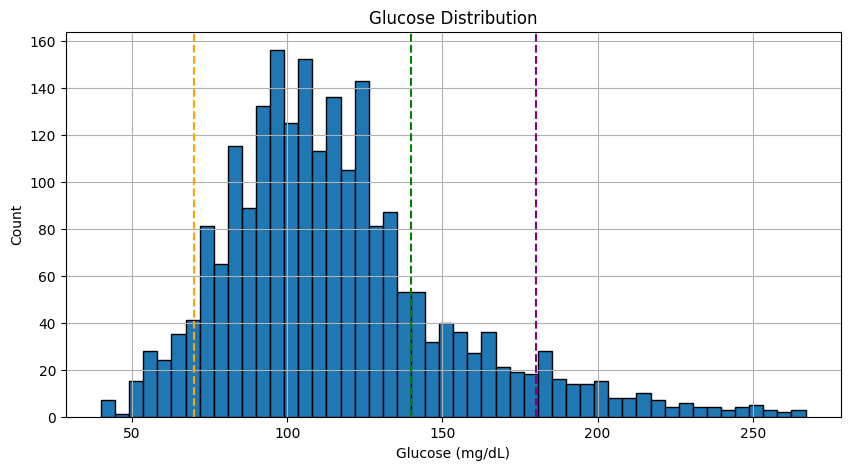

In [28]:
plt.figure(figsize=(10,5))

plt.hist(pkl_glucose, bins=50, edgecolor="black")

plt.axvline(70, color="orange", linestyle="--")
plt.axvline(140, color="green", linestyle="--")
plt.axvline(180, color="purple", linestyle="--")

plt.xlabel("Glucose (mg/dL)"); plt.ylabel("Count"); plt.title("Glucose Distribution");
plt.grid(True); plt.show()

#### Percentage of Samples in Each Glucose Category

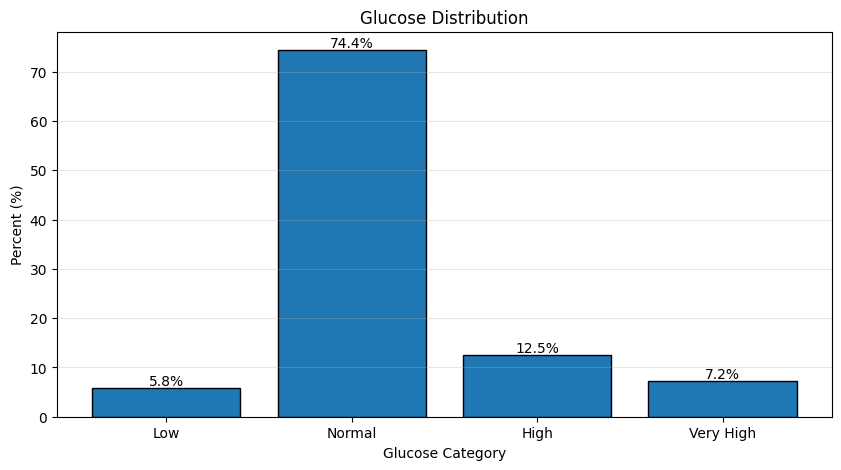

In [29]:
labels = [ "Low", "Normal", "High", "Very High"]

counts = []

for b in range(4):
    counts.append(np.sum(bg_bins == b))

counts = np.array(counts)

percentages = 100 * counts / counts.sum()

plt.figure(figsize=(10,5))

bars = plt.bar( labels, percentages, edgecolor="black")

plt.ylabel("Percent (%)"); plt.xlabel("Glucose Category"); plt.title("Glucose Distribution")
plt.grid(axis="y", alpha=0.3)

for bar, p in zip(bars, percentages):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f"{p:.1f}%",
        ha="center"
    )

plt.show()

#### Overall BG Distribution across clinical bins

In [32]:
for b in np.unique(bg_bins):
  vals3 = pkl_glucose[bg_bins == b]
  print(
      f"Bin {b:>2}: "
      f"min = {vals3.min():>6.1f}, "
      f"max = {vals3.max():>6.1f}, "
      f"count = {len(vals3)}"
  )

Bin  0: min =   40.0, max =   69.0, count = 130
Bin  1: min =   70.0, max =  139.0, count = 1654
Bin  2: min =  140.0, max =  179.0, count = 279
Bin  3: min =  180.0, max =  267.0, count = 161


### Stratified PKL-Based Train-Test Split

In [33]:
# =========================================================
# Stratified split on PKLs
# =========================================================
train_pkl_ids, test_pkl_ids = train_test_split(
    unique_pkl_ids,
    test_size=0.3,
    random_state=42,
    stratify=bg_bins
)

# =========================================================
# Create masks
# =========================================================
train_mask = np.isin(sample_pkl_ids, train_pkl_ids)
test_mask = np.isin(sample_pkl_ids, test_pkl_ids)

# =========================================================
# Final train/test split
# =========================================================
X_train = X[train_mask]
y_train = y[train_mask]
X_test = X[test_mask]
y_test = y[test_mask]

# =========================================================
# Print statistics
# =========================================================
print("Train samples:", len(X_train))
print("Test samples:", len(X_test))
print("Train PKLs:", len(train_pkl_ids))
print("Test PKLs:", len(test_pkl_ids))

# =========================================================
# Check BG distributions
# =========================================================
print("\nTrain BG statistics")
print("Mean:", np.mean(y_train))
print("Std :", np.std(y_train))
print("Min :", np.min(y_train))
print("Max :", np.max(y_train))

print("\nTest BG statistics")
print("Mean:", np.mean(y_test))
print("Std :", np.std(y_test))
print("Min :", np.min(y_test))
print("Max :", np.max(y_test))

Train samples: 20822
Test samples: 8607
Train PKLs: 1556
Test PKLs: 668

Train BG statistics
Mean: 118.21256
Std : 39.356
Min : 40.0
Max : 267.0

Test BG statistics
Mean: 117.97502
Std : 38.13423
Min : 40.0
Max : 259.0


### Normalize Each Sample **(if needed)**

In [17]:
def normalize_each_cycle(sample):
    """
    Normalize each ECG cycle independently.

    Input:
        sample shape = (20,760)
    """

    output = np.zeros_like(sample)

    for i in range(sample.shape[0]):

        cycle = sample[i]

        mean = np.mean(cycle)
        std = np.std(cycle)

        if std < 1e-8:
            output[i] = cycle - mean
        else:
            output[i] = (cycle - mean) / std

    return output

X_train = np.array([normalize_each_cycle(sample) for sample in X_train])

X_test = np.array([normalize_each_cycle(sample) for sample in X_test])

### Plot 1st ECG cycle of train set

mean = -2.3005595
std  = 43.49043
min  = -139.54901
max  = 267.9158


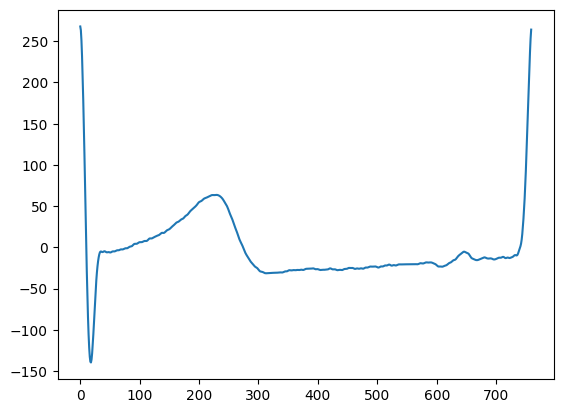

In [34]:
plt.plot(X_train[0,0])
cycle_testi = X_train[0,0]
print("mean =", np.mean(cycle_testi))
print("std  =", np.std(cycle_testi))
print("min  =", np.min(cycle_testi))
print("max  =", np.max(cycle_testi))

# **Dataset Preparation**

### **Create custom PyTorch dataset**

In [35]:
class ECGDataset(Dataset):

    def __init__(self, X, y, transform=None):

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.transform = transform

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        sample = self.X[idx]
        # Add channel dimension
        # (20,760) --> (1,20,760)
        sample = sample.unsqueeze(0)
        label = self.y[idx]

        return sample, label

In [36]:
# =========================================================
# Create datasets
# =========================================================

train_dataset = ECGDataset(X_train, y_train)
test_dataset  = ECGDataset(X_test, y_test)

### **Create dataloaders**

In [37]:
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [38]:
a , b = next(iter(train_loader))
a.shape ,b.shape

(torch.Size([128, 1, 20, 760]), torch.Size([128]))

# **Model Configuration**

### Setting Hyperparameters

In [39]:
LEARNING_RATE = 1e-4
BATCH_SIZE = 128
EPOCHS = 20

### Model, Loss Function, and Optimizer

In [40]:
# =========================================================
# Create model
# =========================================================
model = ResModel().to(DEVICE)

# =========================================================
# Loss and optimizer
# =========================================================
criterion = nn.MSELoss().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


# **Optimization Loop**

### Train function

In [41]:
def train_one_epoch(dataloader, model, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Progress bar
    progress_bar = tqdm(
        dataloader,
        desc="Training",
        leave=False
    )

    for x_batch, y_batch in progress_bar:

        # Move data to device
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        # Forward pass
        predictions = model(x_batch)

        # Compute loss
        loss = criterion(predictions, y_batch)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        all_predictions.extend(predictions.detach().cpu().numpy())
        all_targets.extend(y_batch.detach().cpu().numpy())

        # Update tqdm display
        progress_bar.set_postfix({"batch_loss": f"{loss.item():.4f}"})

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(all_targets, all_predictions))

    epoch_loss = running_loss / len(dataloader)

    return epoch_loss, rmse

### Evaluate function

In [42]:
def evaluate(model, dataloader, criterion, device):

    model.eval()

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    progress_bar = tqdm(dataloader, desc="Evaluating",leave=False)

    with torch.no_grad():
        for x_batch, y_batch in progress_bar:

            # Move data to device
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            # Forward pass
            predictions = model(x_batch)

            # Compute loss
            loss = criterion(predictions, y_batch)

            running_loss += loss.item()

            # Store predictions
            all_predictions.extend(predictions.cpu().numpy())

            # Store targets
            all_targets.extend(y_batch.cpu().numpy())

            progress_bar.set_postfix({"batch_loss": f"{loss.item():.4f}"})

    epoch_loss = running_loss / len(dataloader)

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(all_targets, all_predictions))

    # Calculate MAE
    mae = mean_absolute_error(all_targets, all_predictions)

    return (epoch_loss, rmse, mae, all_predictions, all_targets)

### **Main Epoch Loop**

In [29]:
SAVE_DIR = "/content/drive/MyDrive/RESULT"
os.makedirs(SAVE_DIR, exist_ok=True)

best_rmse = float("inf")
best_epoch = -1
train_losses = []
test_losses = []


for epoch in trange(EPOCHS, desc="Epoch Number"):

    # -----------------------------------------
    # Train for one epoch
    # -----------------------------------------

    train_loss, train_RMSE = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE
    )

    # -----------------------------------------
    # Evaluate model on test set
    # -----------------------------------------

    (test_loss, test_rmse, mae, predictions, targets) = evaluate(
        model=model,
        dataloader=test_loader,
        criterion=criterion,
        device=DEVICE
    )

    # Save losses
    train_losses.append(train_loss)
    test_losses.append(test_loss)


    # Save best model
    if test_rmse < best_rmse:

        best_rmse = test_rmse
        best_epoch = epoch + 1
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, "best_model.pth"))
        print(f"\nNew best model saved " f"(Epoch {best_epoch}, RMSE={best_rmse:.4f})")

    # -----------------------------------------
    # Print results
    # -----------------------------------------

    print(
        f"Epoch {epoch+1:03d}/{EPOCHS} | "
        f"Train Loss: {train_loss:10.4f} | "
        f"Train RMSE: {train_RMSE:10.4f} | "
        f"Test Loss: {test_loss:10.4f} | "
        f"RMSE: {test_rmse:10.4f} | "
        f"MAE: {mae:10.4f}"
    )

Epoch Number:   0%|          | 0/20 [00:00<?, ?it/s]

Training:   0%|          | 0/163 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/68 [00:00<?, ?it/s]


New best model saved (Epoch 1, RMSE=35.9224)
Epoch 001/20 | Train Loss:  1952.7803 | Train RMSE:    44.2044 | Test Loss:  1279.6903 | RMSE:    35.9224 | MAE:    27.8214


Training:   0%|          | 0/163 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/68 [00:00<?, ?it/s]

Epoch 019/20 | Train Loss:   811.1555 | Train RMSE:    28.4871 | Test Loss:  1258.6986 | RMSE:    35.6166 | MAE:    27.8367


Training:   0%|          | 0/163 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/68 [00:00<?, ?it/s]

Epoch 020/20 | Train Loss:   771.3259 | Train RMSE:    27.7661 | Test Loss:  1286.3563 | RMSE:    35.9943 | MAE:    28.3779


# **Results Visualization**

### Loss Curves

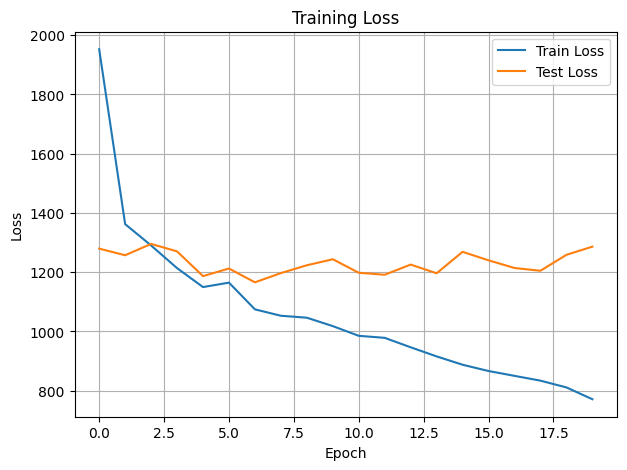

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.grid(True)
plt.show()

### Prediction vs Ground Truth - on **Train Set**

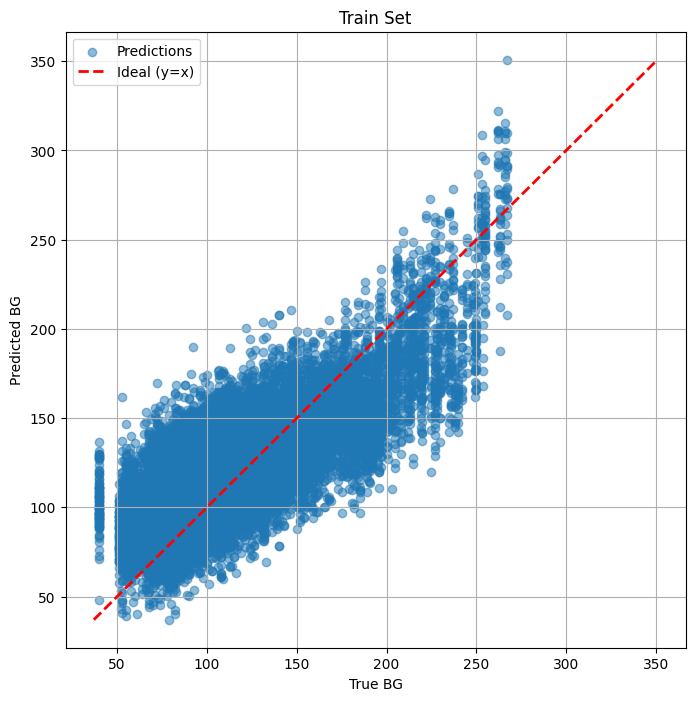

In [33]:
# =========================================================
# Prediction vs Ground Truth(train)
# =========================================================

# =========================================================
# Step 1: Load best checkpoint
# =========================================================
# model.load_state_dict(
#     torch.load("/content/drive/MyDrive/RESULT/best_model.pth", map_location=DEVICE)
# )

model.eval()

train_predictions = []
train_targets = []

with torch.no_grad():

    for x_batch, y_batch in train_loader:

        # Move data to GPU
        x_batch = x_batch.to(DEVICE)

        # Forward pass
        predictions = model(x_batch)

        # Move predictions to CPU
        predictions = predictions.cpu().numpy()

        # Store predictions
        train_predictions.extend(predictions)

        # Store true labels
        train_targets.extend(y_batch.numpy())

# Convert to numpy arrays
train_predictions = np.array(train_predictions)

train_targets = np.array(train_targets)

# =========================================================
# Plot
# =========================================================
plt.figure(figsize=(8,8))
plt.scatter(
    train_targets,
    train_predictions,
    alpha=0.5,
    label="Predictions"
)

# Ideal line y=x
min_val = min(train_targets.min(), train_predictions.min())
max_val = max(train_targets.max(), train_predictions.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label='Ideal (y=x)'
)

plt.legend()
plt.xlabel("True BG")
plt.ylabel("Predicted BG")
plt.title("Train Set")
plt.grid(True)

### Prediction vs Ground Truth - on **Test Set**

C:\Users\Asus\AppData\Local\Temp\ipykernel_14260\1903141654.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(os.path.join(SAVE_DIR, "best_model.pth"), map_loca

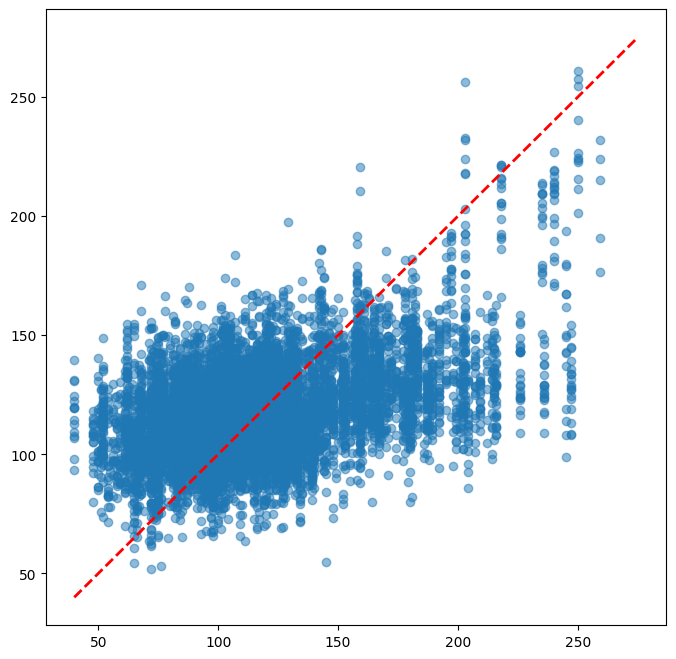

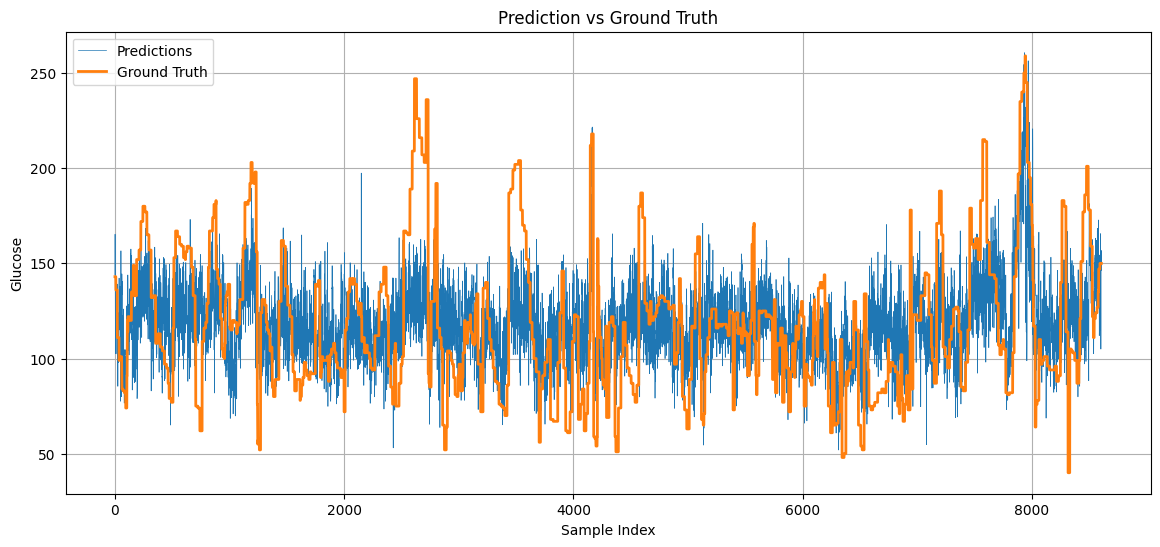

In [43]:
# =========================================================
# Prediction vs Ground Truth
# =========================================================
SAVE_DIR = "Model_Result"

model.load_state_dict(
    torch.load(os.path.join(SAVE_DIR, "best_model.pth"), map_location=DEVICE)
)

model.eval()

test_predictions = []
test_targets = []

with torch.no_grad():

    for x_batch, y_batch in test_loader:

        # Move data to GPU
        x_batch = x_batch.to(DEVICE)

        # Forward pass
        predictions = model(x_batch)

        # Move predictions to CPU
        predictions = predictions.cpu().numpy()

        # Store predictions
        test_predictions.extend(predictions)

        # Store true labels
        test_targets.extend(y_batch.numpy())

# Convert to numpy arrays
test_predictions = np.array(test_predictions)

all_targets = np.array(test_targets)

# =========================================================
# Plot
# =========================================================
plt.figure(figsize=(8,8))
plt.scatter(
    test_targets,
    test_predictions,
    alpha=0.5,
    label = 'Predictions'
)

# Ideal line y=x
# min_val = min(test_targets.min(), test_predictions.min())
# max_val = max(test_targets.max(), test_predictions.max())

plt.plot(
    [40, 275],
    [40, 275],
    'r--',
    linewidth=2,
    label='Ideal (y=x)'
)


plt.figure(figsize=(14,6))
plt.plot(test_predictions, label="Predictions", linewidth=0.5)
plt.plot(all_targets, label="Ground Truth", linewidth=2)

plt.xlabel("Sample Index")
plt.ylabel("Glucose")
plt.title("Prediction vs Ground Truth")
plt.legend()
plt.grid(True)

plt.show()

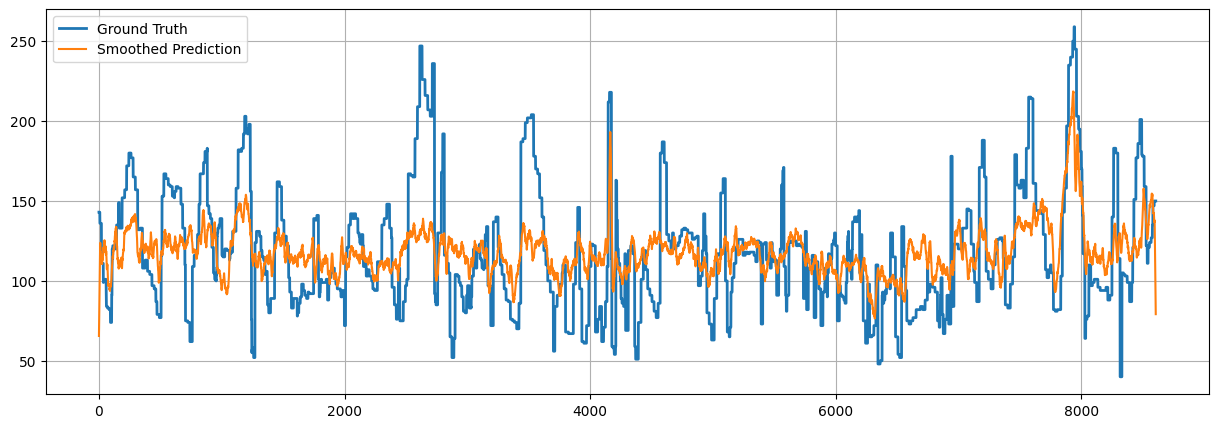

In [44]:
window = 20

smooth_pred = np.convolve(test_predictions, np.ones(window)/window, mode='same')

plt.figure(figsize=(15,5))
plt.plot(test_targets, label="Ground Truth", linewidth=2)
plt.plot(smooth_pred, label="Smoothed Prediction")

plt.legend()
plt.grid(True)
plt.show()

### Correlation Analysis

#### Pearson Correlation on Test Set

In [45]:
corr = np.corrcoef(
    test_targets,
    test_predictions
)[0,1]

print(corr)

0.44819248165677694


#### Mean BG Baseline Analysis (Model vs Baseline Comparison)

In [46]:
mean_bg = np.mean(y_train)

baseline_pred = np.ones_like(y_test) * mean_bg

baseline_rmse = np.sqrt(
    np.mean((baseline_pred - y_test)**2)
)

baseline_rmse, mean_bg, y_train.shape


(np.float32(38.13497), np.float32(118.21256), (20822,))

#### Pearson Correlation on Train Set

In [ ]:
corr_train = np.corrcoef(
    train_targets,
    train_predictions
)[0,1]

print(corr_train)

### Clarke Error Grid Analysis

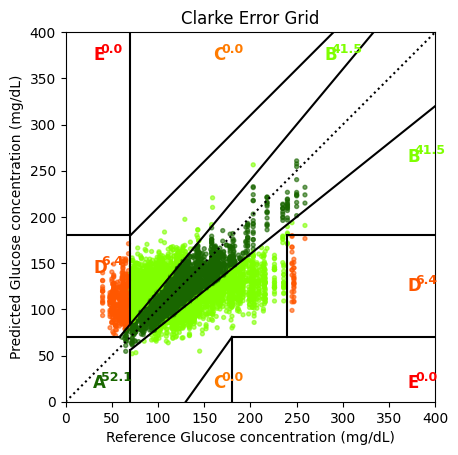

In [73]:
import methcomp

methcomp.clarke(
    reference=test_targets,
    test=test_predictions,
    units='mgdl',
    title='Clarke Error Grid',
    percentage=True,
    square=True
)
plt.xlabel("Reference Glucose concentration (mg/dL)")
plt.ylabel("Predicted Glucose concentration (mg/dL)")
plt.show()